In [7]:
import Shadow
from ophyd import Signal, SignalRO, Component, Device
from optlnls.plot import plot_beam
from optlnls.importing import read_shadow_beam
from bluesky import RunEngine
from bluesky.plans import scan
from bluesky.callbacks.best_effort import BestEffortCallback

RE = RunEngine()
bec = BestEffortCallback()
RE.subscribe(bec)

0

In [8]:
class ShadowEnergy(Signal):

    def set(self, value: float, **kwargs):
        sts = super().set(value, **kwargs)
        self.parent.oe.PH1 = value - self.parent.delta_energy / 2
        self.parent.oe.PH2 = value + self.parent.delta_energy / 2
        return sts

class ShadowAttribute(Signal):

    def set(self, value: float, **kwargs):
        sts = super().set(value, **kwargs)
        oe = self.parent.set_standard_parameters(self.parent.energy.get())
        self.parent.oe = oe
        return sts


class ShadowSource(Device):

    energy = Component(ShadowEnergy, kind="hinted")
    sigmax = Component(ShadowAttribute, kind="hinted")

    def __init__(
        self, name: str, beam: SignalRO, energy: float, delta_energy: float, n_rays: int = 1_000_000
    ):
        super().__init__(name=name)
        self.beam = beam.get()
        self.delta_energy = delta_energy
        self.n_rays = n_rays
        self.oe = self.set_standard_parameters(energy)
        self.energy.set(energy).wait()
        self.sigmax.set(0.033).wait()

    def set_standard_parameters(self, energy):
        oe = Shadow.Source()
        oe.SIGDIX = 0.01
        oe.SIGDIZ = 0.00113
        oe.SIGMAZ = 0.027
        oe.SIGMAX = self.sigmax.get()
        oe.VDIV1 = 0.001
        oe.VDIV2 = 0.001
        oe.FDISTR = 3
        oe.F_COLOR = 3
        oe.F_PHOT = 0
        oe.HDIV1 = 0.004
        oe.HDIV2 = 0.004
        oe.IDO_VX = 0
        oe.IDO_VZ = 0
        oe.IDO_X_S = 0
        oe.IDO_Y_S = 0
        oe.IDO_Z_S = 0
        oe.ISTAR1 = 5676561
        oe.NPOINT = self.n_rays
        oe.PH1 = energy - self.delta_energy / 2
        oe.PH2 = energy + self.delta_energy / 2
        return oe

    def read(self, **kwargs):
        self.beam.genSource(self.oe)
        beam2D = read_shadow_beam(
                beam=self.beam,
                x_column_index=3,
                y_column_index=1
        )
        plot_beam(
            beam2D=beam2D,
            show_plot=True,
            fitType=3,
            textA=2,textB=5,
            x_range=1,x_range_min=-0.1,x_range_max=0.1,
            y_range=1,y_range_min=-0.1,y_range_max=0.1,
            zero_pad_x=2
        )
        return super().read(**kwargs)


In [ ]:
class ShadowM1(Device):
    def __init__(self, beam: Shadow.Beam, past_beamline: list, **kwargs):
        super().__init__(**kwargs)
        self.beam = beam.get()
        self.past_beamline = past_beamline
        self.idx = 0
        oe = Shadow.OE()
        oe.ALPHA = 90.0
        oe.CIL_ANG = 90.0
        oe.DUMMY = 0.1
        oe.FCYL = 1
        oe.FHIT_C = 1
        oe.FMIRR = 1
        oe.FWRITE = 1
        oe.F_EXT = 1
        oe.RLEN1 = 180.0
        oe.RLEN2 = 180.0
        oe.RMIRR = 2108.8753452152337
        oe.RWIDX1 = 20.0
        oe.RWIDX2 = 20.0
        oe.T_IMAGE = 35.0
        oe.T_INCIDENCE = 80.825
        oe.T_REFLECTION = 80.825
        oe.T_SOURCE = 0.0
        self.oe = oe

    def read(self, **kwargs):
        self.beam.traceOE(self.oe, self.idx)
        beam2D = read_shadow_beam(
                beam=self.beam,
                x_column_index=3,
                y_column_index=1
        )
        plot_beam(
            beam2D=beam2D,
            show_plot=True,
            fitType=3,
            textA=2,textB=5,
            x_range=1,x_range_min=-0.2,x_range_max=0.2,
            y_range=1,y_range_min=-0.2,y_range_max=0.2,
            zero_pad_x=2
        )
        return super().read(**kwargs)


In [10]:
class OphyBeam(Device):

    width = Component(SignalRO, kind="hinted")

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.beam = Shadow.Beam()

    def get(self, **kwargs):
        return self.beam

 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE


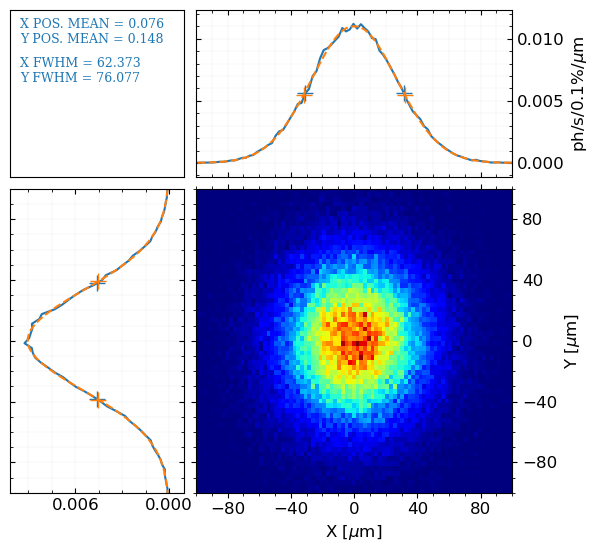

 Call to RESET
 Exit from RESET
 Call to SETSOUR
 Exit from SETSOUR
 Call to IMREF
 Exit from IMREF
 Call to OPTAXIS
 Exit from OPTAXIS
 Call to MSETUP
 Exit from MSETUP
 Call to RESTART
 Exit from RESTART
 Call to MIRROR
 Exit from MIRROR
 Call to IMAGE
 Exit from IMAGE
 Call to DEALLOC
 Exit from DEALLOC


/opt/micromamba/envs/bl-auto-align/lib/python3.11/site-packages/optlnls/math.py:16: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.sum(f_x*np.square(x))/np.sum(f_x) - (np.sum(f_x*x)/np.sum(f_x))**2)


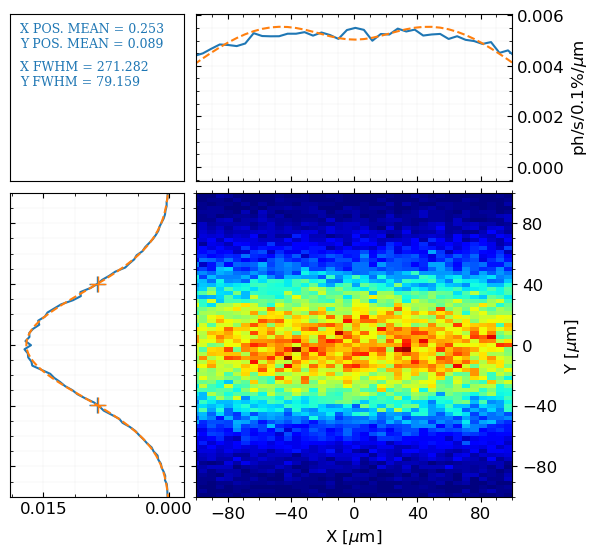

In [14]:

beamline = []
Shadow.Beam()

beam = OphyBeam(name="beam")

beamline.append(
    ShadowSource(
        name="src",
        beam = beam,
        energy=20000,
        delta_energy=1000,
        n_rays=100_000
))

past_beamline = beamline.copy()

beamline.append(
    ShadowM1(
        name="m1",
        beam = beam,
        past_beamline=past_beamline
))


for device in beamline:
    device.read()



Transient Scan ID: 1     Time: 2026-04-09 13:57:27
Persistent Unique Scan ID: '193fbff8-b695-400f-af55-2e838262aa6e'
 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE


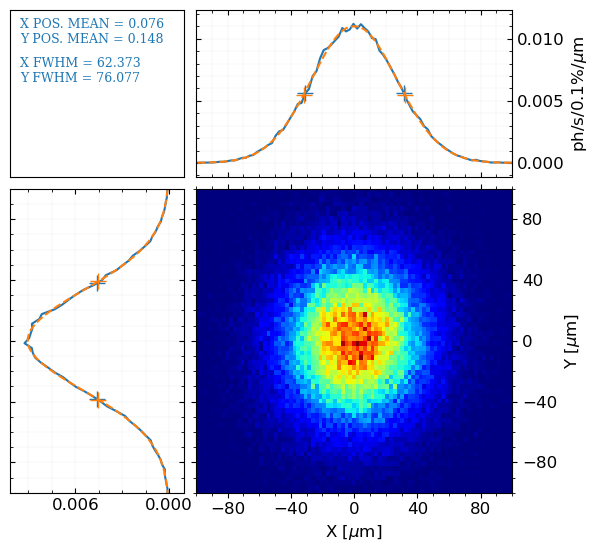

New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time | src_sigmax | src_energy |
+-----------+------------+------------+------------+
|         1 | 13:57:28.3 |      0.033 |         20 |
 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE


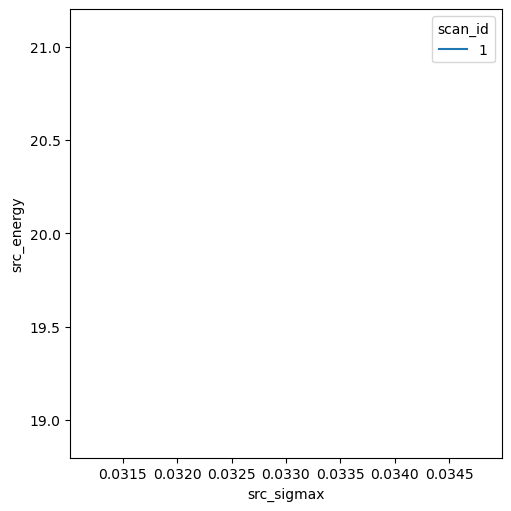

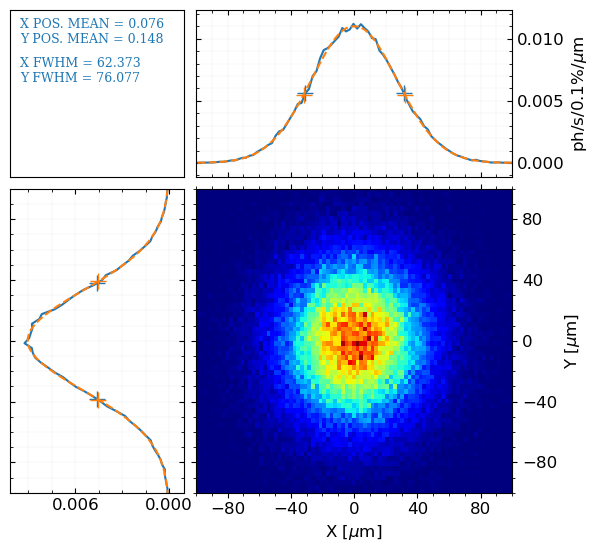

|         2 | 13:57:29.6 |      0.150 |         20 |
 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE


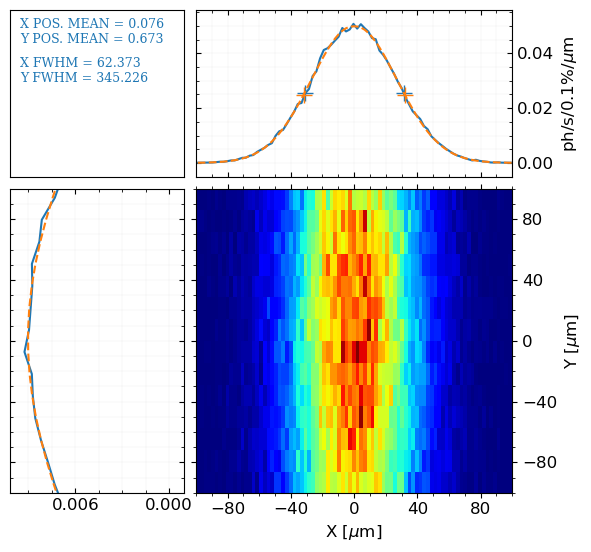

|         3 | 13:57:30.9 |      0.266 |         20 |
 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE


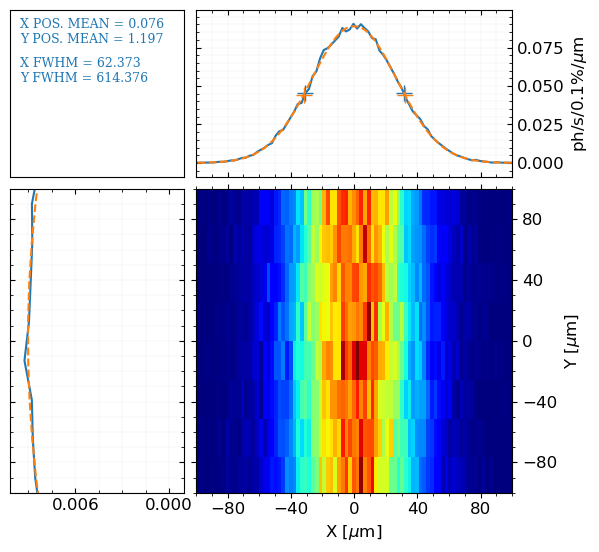

|         4 | 13:57:32.2 |      0.383 |         20 |
 Generated         5000  rays out of       100000
                  10000
                  15000
                  20000
                  25000
                  30000
                  35000
                  40000
                  45000
                  50000
                  55000
                  60000
                  65000
                  70000
                  75000
                  80000
                  85000
                  90000
                  95000
                 100000
 Exit from SOURCE


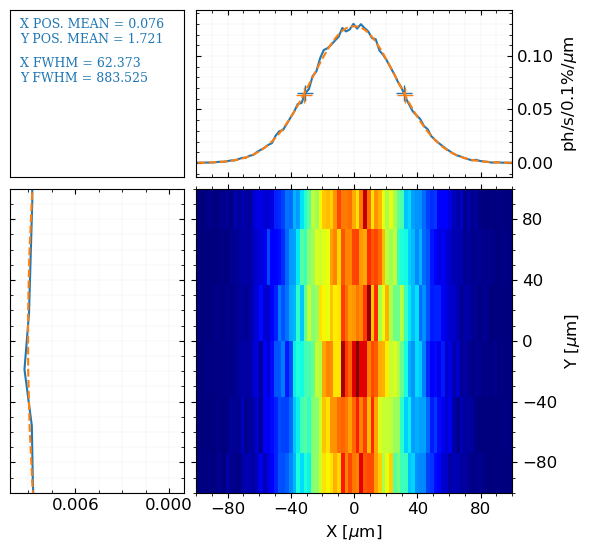

|         5 | 13:57:33.5 |      0.500 |         20 |
+-----------+------------+------------+------------+
generator scan ['193fbff8'] (scan num: 1)





('193fbff8-b695-400f-af55-2e838262aa6e',)

In [ ]:
source = ShadowSource(
    name="src",
    beam = beam,
    energy=20,
    delta_energy=1,
    n_rays=100_000
)

RE(scan([source], source.sigmax,  0.033, 0.5, num = 5))